### Baseline weather detection model (Random Forest as the baseline algorithm)

**Results from the workshop:**

| Model               | Acc%    | Speed        |
|---------------------|---------|--------------|
| Random Forest       | ~91-94% | < 0.01 sec   |
| Logistic Regression | ~88-91% | < 0.0001 sec |
| SVM (Linear)        | ~89%    | < 0.006 sec  |
| SVM (RBF)           | ~92-93% | < 0.01 sec   |
| KNN                 | ~92-93% | < 0.01 sec   |


Instructor also quickly experimented with XGBoost, AdaBoost, MLP and GaussianProcessClassifier, however, their results were similar to Random Forest or slightly worse. 

GaussianProcessClassifier was also surprisingly slow (over 0.3 seconds).

**FINAL VERDICT:** You can use any model from above (except Linear SVC, since it seems to underpeform slightly and it's slower than logistic regression)

In [1382]:
# usual imports in a classic ML pipeline for Classification
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import metrics

# we can import the random forest algorithms from 
# scikit-learn's ensemble -features
from sklearn.ensemble import RandomForestClassifier

# additional metrics ONLY for classification
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

# let's add some helpful features like the pipelines
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [1383]:
# load the data
df = pd.read_csv("digitraffic_weather_balanced_ver1_2026.csv")

# let's quickly see the first 5 rows of data
df

,dew_point,avg_wind,humidity,rain,rain_sum,snow_depth,rain_amount,snow_amount,ice_measure,friction,ice_frequency,mean_temperature,condition
0,-12.700000,5.500000,47.000000,0.000000,0.00000,0.0,0.000000,0.00000,0.000000,0.820000,487.0,-8.800000,Normal
1,-10.584339,3.856224,82.055339,1.155024,2.57065,0.0,0.010964,0.16092,0.000000,0.806557,105.0,-5.204363,Ice
2,-3.200000,2.100000,96.000000,4.000000,2.10000,0.0,0.000000,0.34000,0.110000,0.380000,112.0,-8.100000,Snow
3,0.400000,0.900000,98.000000,0.000000,0.70000,0.0,0.020000,0.00000,0.000000,0.820000,465.0,4.550000,Rain
4,-10.154048,1.549590,86.478021,0.437110,0.00000,0.0,0.180977,0.00000,0.262158,0.686309,105.0,-2.060633,Ice
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2122,-2.500000,2.600000,97.000000,4.000000,1.30000,16.0,0.000000,0.18000,0.170000,0.260000,110.0,-5.800000,Snow
2123,3.500000,2.100000,59.000000,0.000000,0.00000,0.0,0.000000,0.00000,0.000000,0.820000,112.0,6.400000,Rain
2124,0.500000,1.400000,93.000000,1.000000,1.40000,0.0,0.590000,0.00000,0.000000,0.660000,115.0,-1.000000,Rain
2125,-2.700000,5.600000,92.000000,4.000000,0.80000,4.0,0.280000,0.00000,0.000000,0.710000,112.0,-0.700000,Snow


In [1384]:
# check duplicates, we have a few
df.duplicated().sum()

np.int64(36)

In [1385]:
# drop the duplicates
df = df.drop_duplicates()

In [1386]:
# condition is our target variable, let's check the balance
df['condition'].value_counts()

condition
Rain      595
Normal    570
Snow      511
Ice       415
Name: count, dtype: int64

In [1387]:
# no missing values anywhere
df.isna().sum()

dew_point           0
avg_wind            0
humidity            0
rain                0
rain_sum            0
snow_depth          0
rain_amount         0
snow_amount         0
ice_measure         0
friction            0
ice_frequency       0
mean_temperature    0
condition           0
dtype: int64

In [1388]:
# this is technically not required in most algorithms
# but for easier testing, let's encode the target
mapping = {"Ice": 0, "Normal": 1, "Rain": 2, "Snow": 3}
df['condition'] = df['condition'].map(mapping)

# save also the labels for easier metrics and model usage with new data
labels = ["Ice", "Normal", "Rain", "Snow"]

C:\Users\tuomas.valtanen\AppData\Local\Temp\ipykernel_21036\2731686899.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['condition'] = df['condition'].map(mapping)


### X/y and train/test -splits

In [1389]:
# first step, we split our data into SUPPORT variables and the TARGET variable
# X => support variables, y => target variable

# X => list of support variables the model uses 
# while predicting the target variable with the model
X = df.drop("condition", axis=1)

# our target variable is y
y = df['condition']

In [1390]:
# secondly, train/test -split with scikit-learn's helper function
# 0.3 for testing => 30% of data is reserved for testing purposes
# and based on that => it's deduced that 70% will be in the training data

# you can also define the random state, which is sometimes useful
# if you want to "lock down" all the randomness in order to get same results every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

### Train the model

In [1391]:
# create the model and train it with the data
# model = LogisticRegression()

# Pipeline is super helpful here, since we can integrate the scaler
# before the model, no need to manually scale anything
model = make_pipeline(StandardScaler(), RandomForestClassifier())
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('randomforestclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


### Let's have a small benchmark => how fast is this model in practice

In [1392]:
# time measurement code from ChatGPT originally
import time

# Record the start time
start_time = time.time()

# Perform the prediction
predictions = model.predict(X_test)

# Record the end time
end_time = time.time()

# Calculate the total time taken
total_time = end_time - start_time

# Print the total time
print(f"Total time for predictions: {total_time:.4f} seconds")

Total time for predictions: 0.0105 seconds


### Classification error metrics

In [1393]:
# we need to create test predictions based on our earlier reserved test dataset
# this data has never been seen by the model by now
predictions = model.predict(X_test)

Random Forest with default settings, accuracies are usualy between 91-93% 

In [1394]:
# print the classification report based on true values and predictions
print(classification_report(y_test, predictions))

# get overall accuracy of the model and print it
acc = accuracy_score(y_test, predictions)
print("\nModel overall accuracy: {:.2f}%".format(acc * 100))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       111
           1       0.93      0.89      0.91       133
           2       0.91      0.88      0.89       144
           3       0.92      0.99      0.96       135

    accuracy                           0.93       523
   macro avg       0.93      0.93      0.93       523
weighted avg       0.93      0.93      0.93       523


Model overall accuracy: 93.12%


<Axes: >

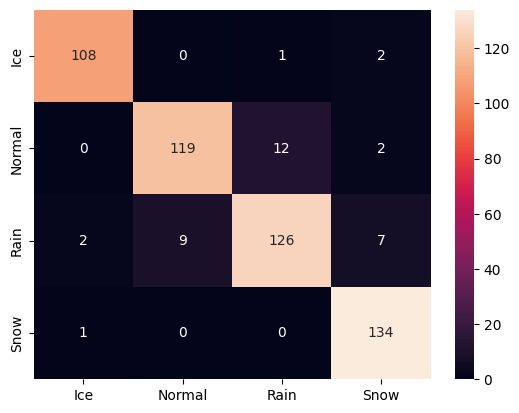

In [1395]:
# see the confusion matrix
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='g',
            xticklabels=labels, yticklabels=labels)


In [1396]:
# The AUC score is a super sensitive metric
# you often get low scores, even 0.5

# in binary logistic regression, AUC values are often interpreted as follows:
# A binary classifier is useful only when it achieves ROC-AUC score greater than 0.5 and as near to 1 as possible. 
# If a classifier yields a score less than 0.5, it simply means that the model is performing worse 
# than a random classifier, and therefore is useless.

# In multinomial logistic regression , AUC values are often interpreted as follows: 
# 0.5-0.6 (failed)
# 0.6-0.7 (worthless)
# 0.7-0.8 (poor)
# 0.8-0.9 (good)
# > 0.9 (excellent)

# basically 0.5 means you could get the same result with just random guessing
roc_auc_score(y_test, model.predict_proba(X_test), multi_class="ovr")

0.9848866604001534

### Using the model in practice

In [1397]:
df.columns

Index(['dew_point', 'avg_wind', 'humidity', 'rain', 'rain_sum', 'snow_depth',
       'rain_amount', 'snow_amount', 'ice_measure', 'friction',
       'ice_frequency', 'mean_temperature', 'condition'],
      dtype='object')

In [1398]:
df.head(3)

,dew_point,avg_wind,humidity,rain,rain_sum,snow_depth,rain_amount,snow_amount,ice_measure,friction,ice_frequency,mean_temperature,condition
0,-12.700000,5.500000,47.000000,0.000000,0.00000,0.0,0.000000,0.00000,0.00,0.820000,487.0,-8.800000,1
1,-10.584339,3.856224,82.055339,1.155024,2.57065,0.0,0.010964,0.16092,0.00,0.806557,105.0,-5.204363,0
2,-3.200000,2.100000,96.000000,4.000000,2.10000,0.0,0.000000,0.34000,0.11,0.380000,112.0,-8.100000,3


In [1399]:
# usually in GUI application we save the model-object / variable into a file (by using joblib-module)
# and in the GUI application => we load the saved model from the file
# and use the model just like here below

# map all the variables from the user
# into a Python dictionary
# the variable names have to match with the original dataset

# -3.200000	2.100000	96.000000	4.000000	2.10000	0.0	0.000000	0.34000	0.11	0.380000	112.0	-8.100000	
tester_row = {
    'dew_point': -3.2, 
    'avg_wind': 2.1, 
    'humidity': 96.0, 
    'rain': 4.0, 
    'rain_sum': 2.1, 
    'snow_depth': 0.0,
    'rain_amount': 0.0, 
    'snow_amount': 0.34, 
    'ice_measure': 0.11, 
    'friction': 0.38,
    'ice_frequency': 112.0, 
    'mean_temperature': -8.1
}

# convert to pandas format
tester_row = pd.DataFrame([tester_row])

In [1400]:
print("All probabilities by category:")
print(labels)
print(model.predict_proba(tester_row))
print()

print("Weather prediction based on the given data:")
result = labels[model.predict(tester_row)[0]]
print(result)
print("-------------------")

All probabilities by category:
['Ice', 'Normal', 'Rain', 'Snow']
[[0.03 0.   0.   0.97]]

Weather prediction based on the given data:
Snow
-------------------


### Let's test the model with a simulated weather API

In [1401]:
import urllib.request, json

data = None

with urllib.request.urlopen("https://edu.frostbit.fi/api/road_weather/2025/") as url:
    data = json.load(url)


if data != None:
    print(data)
    print()

    # convert to pandas format
    tester_row = pd.DataFrame([data])

    print("All probabilities by category:")
    print(labels)
    print(model.predict_proba(tester_row))
    print()

    print("Weather prediction based on the given data:")
    result = labels[model.predict(tester_row)[0]]
    print(result)
    print("-------------------")

{'dew_point': 5.42, 'avg_wind': 1.58, 'humidity': 97.43, 'rain': 0, 'rain_sum': 4.970000000000001, 'snow_depth': 0, 'rain_amount': 0.34, 'snow_amount': 0, 'ice_measure': 0, 'friction': 0.71, 'ice_frequency': 110.83, 'mean_temperature': -3.3200000000000003}

All probabilities by category:
['Ice', 'Normal', 'Rain', 'Snow']
[[0.   0.   0.99 0.01]]

Weather prediction based on the given data:
Rain
-------------------


In [1402]:
f = open("api_data.json")
all_data = json.load(f)

# initialize a dictionary for calculating different conditions
# to check how balanced our model's predictions are for the RC car
report = {
    "Normal": 0,
    "Ice": 0,
    "Rain": 0,
    "Snow": 0
}

for data in all_data:
    # let's use this in the model, prediction
    tester_row = pd.DataFrame([data])
    result = labels[model.predict(tester_row)[0]]
    report[result] += 1

f.close()

print(report)

{'Normal': 19, 'Ice': 10, 'Rain': 18, 'Snow': 13}


### Let's save our model to a joblib-file so we can use it in other applications

In [1403]:
# save the model into a file, check out the file
# => weather_control_model1
from joblib import dump
dump(model, "weathercontrolmodel1.joblib")

['weathercontrolmodel1.joblib']